# Traffic Prediction Dataset Analysis

This notebook analyzes traffic data based on vehicle counts, date, day of the week, and traffic situation. The goal is to understand traffic patterns and identify the main factors related to traffic congestion.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [20]:
df = pd.read_csv("Traffic.csv")

## 1. Dataset Overview

The dataset contains traffic records collected at 15-minute intervals. It includes vehicle counts for cars, bikes, buses, and trucks. The target column is Traffic Situation, which describes the level of traffic congestion.

In [31]:

df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


In [10]:
df.shape

(2976, 9)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Time               2976 non-null   str  
 1   Date               2976 non-null   int64
 2   Day of the week    2976 non-null   str  
 3   CarCount           2976 non-null   int64
 4   BikeCount          2976 non-null   int64
 5   BusCount           2976 non-null   int64
 6   TruckCount         2976 non-null   int64
 7   Total              2976 non-null   int64
 8   Traffic Situation  2976 non-null   str  
dtypes: int64(6), str(3)
memory usage: 209.4 KB


In [14]:
df.isnull().sum()

Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64

### Data Cleaning Result

The dataset has 2,976 rows and 9 columns. There are no missing values in the dataset, so no rows or columns need to be removed. The dataset is ready for analysis.

----

In [33]:
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

## 2. Research Question 1

RQ1 交通情况分布

### What is the distribution of traffic situations?

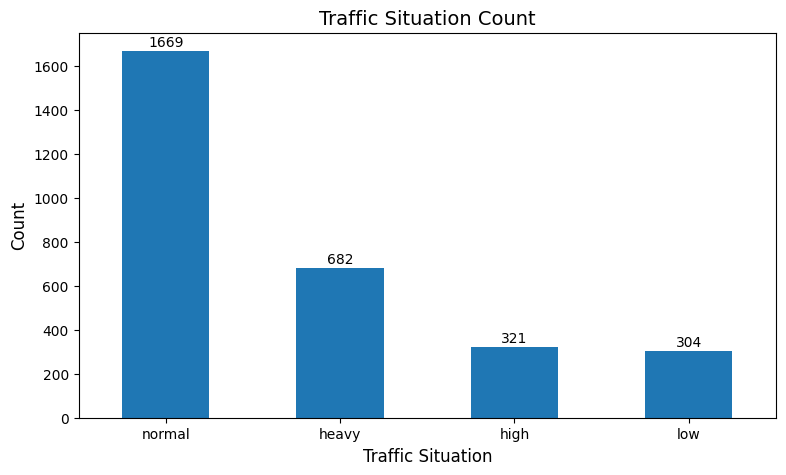

In [34]:
traffic_counts = df["Traffic Situation"].value_counts()

ax = traffic_counts.plot(kind="bar")

plt.title("Traffic Situation Count")
plt.xlabel("Traffic Situation")
plt.ylabel("Count")
plt.xticks(rotation=0)

for i, value in enumerate(traffic_counts):
    plt.text(i, value + 20, str(value), ha="center")

plt.show()

Normal traffic is the most common situation, with 1,669 records. Heavy traffic is the second most common situation, with 682 records. High and low traffic situations appear less frequently. This shows that most traffic conditions are normal, but congestion-related situations are still significant.

## 3. Research Question 2

### Which day of the week has the highest average total traffic?

RQ2 每周哪一天车流量最高

In [20]:
day_total = df.groupby("Day of the week")["Total"].mean().sort_values(ascending=False)

day_total

Day of the week
Wednesday    116.362500
Saturday     115.848958
Tuesday      115.239583
Thursday     114.562500
Sunday       114.356771
Monday       112.958333
Friday       109.322917
Name: Total, dtype: float64

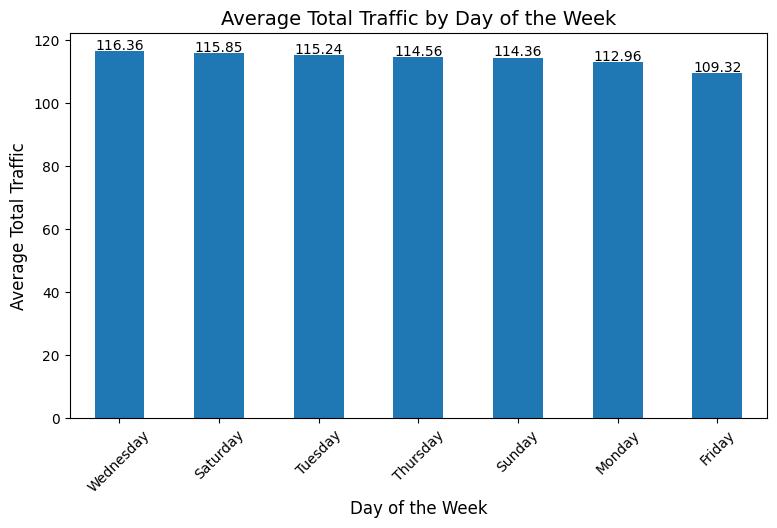

In [35]:
ax = day_total.plot(kind="bar")

plt.title("Average Total Traffic by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Total Traffic")
plt.xticks(rotation=45)

for i, value in enumerate(day_total):
    plt.text(i, value + 0.5, round(value, 2), ha="center")

plt.show()

Wednesday has the highest average total traffic, while Friday has the lowest. However, the differences between days are small. This suggests that the day of the week does not have a very strong effect on total traffic volume in this dataset.

## 4. Research Question 3

### Which vehicle type contributes the most to traffic volume?

RQ3 哪种车辆最多

In [22]:
vehicle_avg = df[["CarCount", "BikeCount", "BusCount", "TruckCount"]].mean().sort_values(ascending=False)

vehicle_avg

CarCount      68.696573
TruckCount    15.324933
BusCount      15.279570
BikeCount     14.917339
dtype: float64

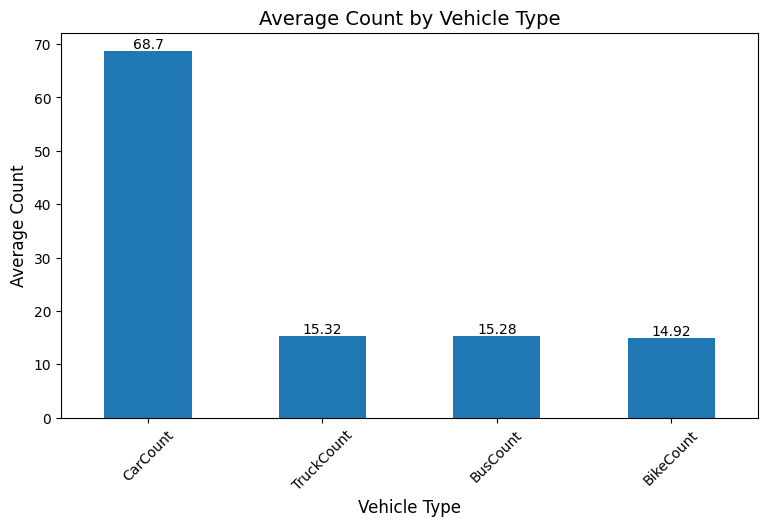

In [36]:
ax = vehicle_avg.plot(kind="bar")

plt.title("Average Count by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Count")
plt.xticks(rotation=45)

for i, value in enumerate(vehicle_avg):
    plt.text(i, value + 0.5, round(value, 2), ha="center")

plt.show()

Cars have the highest average count among all vehicle types. The average car count is much higher than trucks, buses, and bikes. This suggests that cars are the main contributor to total traffic volume.

## 5. Research Question 4

### How do vehicle counts differ across traffic situations?

In [24]:
traffic_vehicle_avg = df.groupby("Traffic Situation")[["CarCount", "BikeCount", "BusCount", "TruckCount", "Total"]].mean()

traffic_vehicle_avg

,CarCount,BikeCount,BusCount,TruckCount,Total
Traffic Situation,,,,,
heavy,130.887097,29.775660,33.014663,5.181818,198.859238
high,82.853583,16.183801,22.841121,20.554517,142.433022
low,42.960526,9.779605,4.486842,7.766447,64.993421
normal,45.248652,9.538047,8.544038,19.840623,83.171360


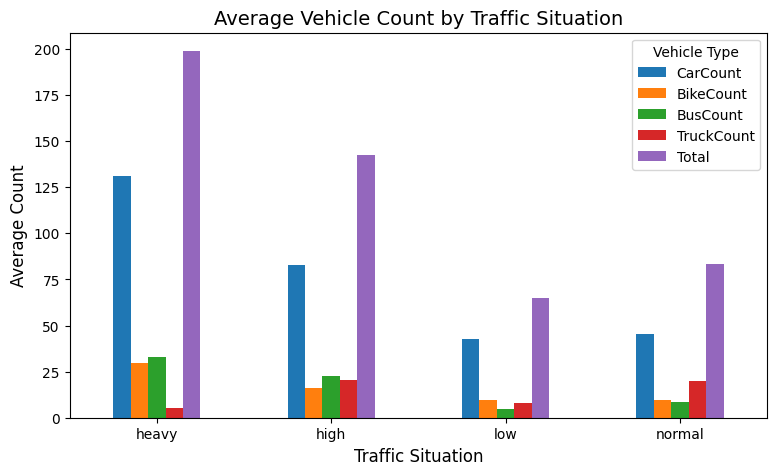

In [37]:
traffic_vehicle_avg.plot(kind="bar")

plt.title("Average Vehicle Count by Traffic Situation")
plt.xlabel("Traffic Situation")
plt.ylabel("Average Count")
plt.xticks(rotation=0)
plt.legend(title="Vehicle Type")

plt.show()

Heavy traffic has the highest average total vehicle count, followed by high traffic. Normal and low traffic situations have much lower total counts. Cars are the dominant vehicle type in every traffic situation. This indicates that traffic congestion is strongly related to the total number of vehicles, especially cars.

## 6. Research Question 5

### How does average total traffic change across dates?

RQ5 日期和车流量变化

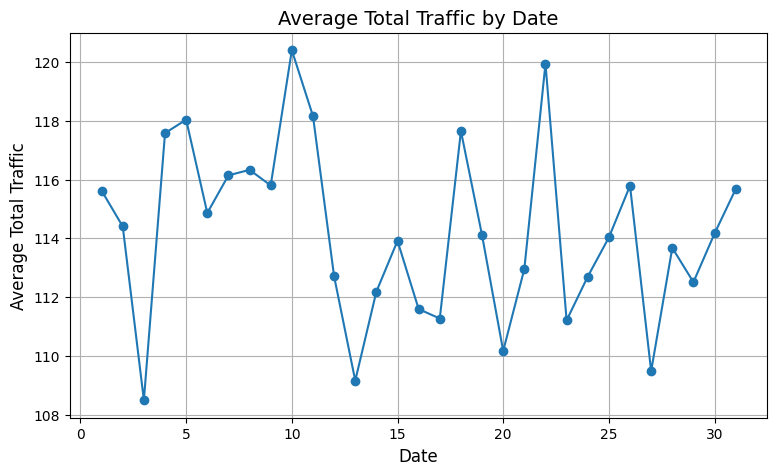

In [38]:
date_total = df.groupby("Date")["Total"].mean()

date_total.plot(kind="line", marker="o")

plt.title("Average Total Traffic by Date")
plt.xlabel("Date")
plt.ylabel("Average Total Traffic")
plt.grid(True)

plt.show()

The average total traffic fluctuates across dates. Some peaks appear around Date 10 and Date 22, while lower traffic appears around Date 3, Date 13, and Date 27. Overall, the daily traffic changes are moderate and remain within a relatively narrow range.

-----

## 7. Traffic Situation Prediction Model

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("sklearn imported successfully")

sklearn imported successfully


### Model 1: Decision Tree with Total Column

In this model, a Decision Tree Classifier is used to predict Traffic Situation based on date, day of the week, individual vehicle counts, and total traffic volume.

The Total column is included in this model, so the model may achieve very high accuracy because Traffic Situation is likely related to total vehicle count.

In [8]:
model_df = df.copy()

le_day = LabelEncoder()
le_target = LabelEncoder()

model_df["Day of the week"] = le_day.fit_transform(model_df["Day of the week"])
model_df["Traffic Situation"] = le_target.fit_transform(model_df["Traffic Situation"])

X = model_df[["Date", "Day of the week", "CarCount", "BikeCount", "BusCount", "TruckCount", "Total"]]
y = model_df["Traffic Situation"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)

accuracy

1.0

In [12]:
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

              precision    recall  f1-score   support

       heavy       1.00      1.00      1.00       127
        high       1.00      1.00      1.00        63
         low       1.00      1.00      1.00        66
      normal       1.00      1.00      1.00       340

    accuracy                           1.00       596
   macro avg       1.00      1.00      1.00       596
weighted avg       1.00      1.00      1.00       596



### Model Result

The Decision Tree Classifier achieved an accuracy of 1.00 on the test set. The precision, recall, and F1-score for all traffic situation classes are also 1.00. This means that the model correctly predicted all test samples.

However, this very high accuracy may be caused by the inclusion of the Total column. Since Traffic Situation is likely created based on total vehicle count, the model can easily learn the classification rule. Therefore, the result should be interpreted carefully.

---

### Model 2: Decision Tree without Total Column

To avoid relying too much on the Total column, a second Decision Tree Classifier is built using only date, day of the week, and individual vehicle counts.

This model provides a more realistic evaluation because it does not directly use the Total vehicle count.

In [13]:
X_without_total = model_df[["Date", "Day of the week", "CarCount", "BikeCount", "BusCount", "TruckCount"]]
y = model_df["Traffic Situation"]

X_train, X_test, y_train, y_test = train_test_split(
    X_without_total,
    y,
    test_size=0.2,
    random_state=42
)

model_without_total = DecisionTreeClassifier(random_state=42)

model_without_total.fit(X_train, y_train)

y_pred_without_total = model_without_total.predict(X_test)

accuracy_without_total = accuracy_score(y_test, y_pred_without_total)

accuracy_without_total

0.9278523489932886

In [14]:
print(classification_report(y_test, y_pred_without_total, target_names=le_target.classes_))

              precision    recall  f1-score   support

       heavy       0.93      0.92      0.92       127
        high       0.81      0.83      0.82        63
         low       0.97      0.92      0.95        66
      normal       0.94      0.95      0.95       340

    accuracy                           0.93       596
   macro avg       0.91      0.91      0.91       596
weighted avg       0.93      0.93      0.93       596



### Model Without Total Column Result

After removing the Total column, the Decision Tree Classifier achieved an accuracy of about 92.8%. This is lower than the previous model with the Total column, but it is still a strong result.

The model performs well for most traffic situations. The normal class has the highest support because it appears most frequently in the dataset. The high class has a slightly lower F1-score compared with the other classes, which means it is a little harder for the model to predict correctly.

Overall, this result shows that individual vehicle counts, such as car, bike, bus, and truck counts, are still useful for predicting traffic situations even without using the Total column.

----

Two models were tested. The first model included the Total column and achieved 100% accuracy. However, this may be because Traffic Situation is closely related to Total vehicle count. Therefore, a second model was built without the Total column. The second model achieved about 92.8% accuracy, which provides a more realistic evaluation.

---

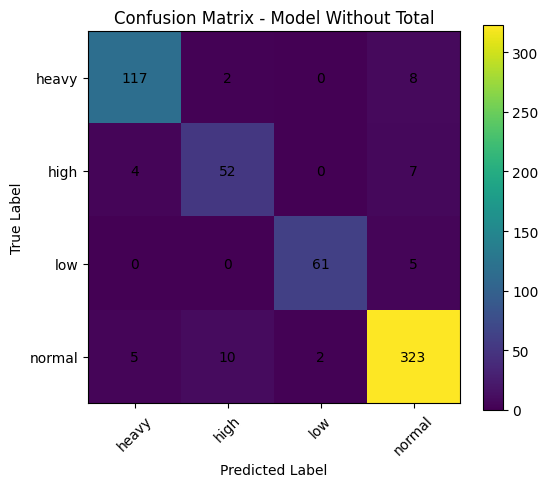

In [15]:
cm = confusion_matrix(y_test, y_pred_without_total)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Model Without Total")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(le_target.classes_)), le_target.classes_, rotation=45)
plt.yticks(range(len(le_target.classes_)), le_target.classes_)

for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

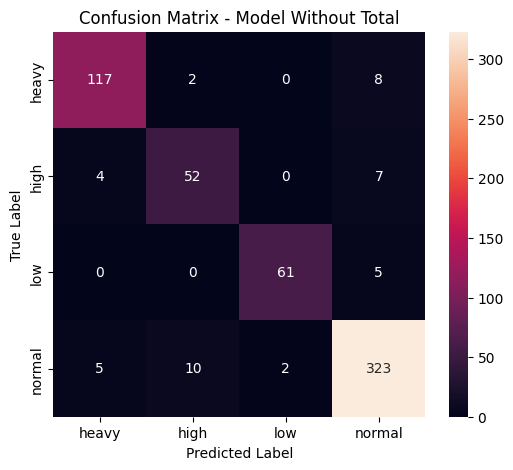

In [18]:

cm = confusion_matrix(y_test, y_pred_without_total)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_
)

plt.title("Confusion Matrix - Model Without Total")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The confusion matrix shows that most predictions are correct. The model performs especially well for the normal class. Some errors occur between high, heavy, and normal traffic situations, which may be because these categories can have similar vehicle count patterns.

---

In [28]:
df["Traffic Situation"].value_counts()

Traffic Situation
normal    1669
heavy      682
high       321
low        304
Name: count, dtype: int64

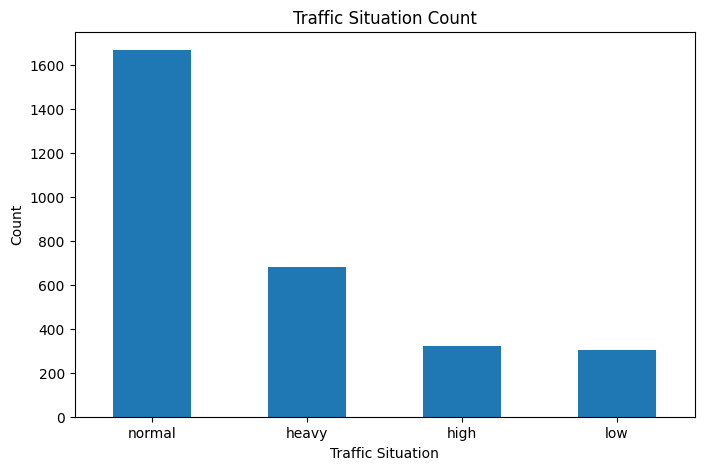

In [29]:
traffic_counts = df["Traffic Situation"].value_counts()

traffic_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Traffic Situation Count")
plt.xlabel("Traffic Situation")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 8. Overall Conclusion

This project analyzed a traffic prediction dataset containing 2,976 records and 9 columns. The dataset has no missing values, so it was ready for exploratory data analysis and machine learning.

The exploratory analysis shows that normal traffic is the most common traffic situation, followed by heavy traffic. Cars are the dominant vehicle type in the dataset and contribute the most to total traffic volume. The average total traffic is highest on Wednesday and lowest on Friday, although the difference between days is relatively small. The analysis also shows that heavy traffic has the highest average total vehicle count, which suggests that congestion is strongly related to the number of vehicles, especially cars.

A Decision Tree Classifier was used to predict traffic situations. The first model included the Total column and achieved 100% accuracy. However, this result may be too optimistic because Traffic Situation is likely closely related to total vehicle count. Therefore, a second model was built without the Total column. This model achieved about 92.8% accuracy, which is a more realistic result. The confusion matrix shows that most predictions are correct, although some high, heavy, and normal traffic situations are confused with each other.

Overall, the project shows that vehicle count data can be used effectively to understand traffic patterns and predict traffic situations.